In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd

In [2]:
#Load dataset
Dibetes_df = pd.read_csv('diabetes_dataset.csv')

In [3]:
### Data Simple info
Dibetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

### EDA Step 1 : Data Cleaning 

#### Check Missing Values

In [4]:
## looking For Null values in Data Frame
Dibetes_df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


There are no null values in the data frame

In [5]:
# Describe the dataset
Dibetes_df.describe().round(2)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50.12,2.00,118.91,5.99,7.00,6.00,0.22,0.25,0.08,25.61,...,185.98,54.04,103.00,121.46,111.12,160.04,9.06,6.52,30.22,0.60
std,15.60,1.42,84.41,1.78,1.09,2.47,0.41,0.43,0.27,3.59,...,32.01,10.27,33.39,43.37,13.60,30.94,4.95,0.81,9.06,0.49
min,18.00,0.00,0.00,0.00,3.00,0.50,0.00,0.00,0.00,15.00,...,100.00,20.00,50.00,30.00,60.00,70.00,2.00,4.00,2.70,0.00
25%,39.00,1.00,57.00,4.80,6.30,4.30,0.00,0.00,0.00,23.20,...,164.00,47.00,78.00,91.00,102.00,139.00,5.09,5.97,23.80,0.00
50%,50.00,2.00,100.00,6.00,7.00,6.00,0.00,0.00,0.00,25.60,...,186.00,54.00,102.00,121.00,111.00,160.00,8.79,6.52,29.00,1.00
75%,61.00,3.00,160.00,7.20,7.70,7.70,0.00,1.00,0.00,28.00,...,208.00,61.00,126.00,151.00,120.00,181.00,12.45,7.07,35.60,1.00
max,90.00,10.00,833.00,10.00,10.00,16.80,1.00,1.00,1.00,39.20,...,318.00,98.00,263.00,344.00,172.00,287.00,32.22,9.80,67.20,1.00


The dataset seems balanced and clean (no missing values).

Population is middle-aged, slightly overweight, and moderately active.

Prediabetes and diabetes are common — elevated glucose and HbA1c levels support this.

Lifestyle risk factors: high screen time, moderate diet and physical activity.

Medical comorbidities (hypertension 25%, cardiovascular 8%) add to overall metabolic risk.

Risk model seems to align with actual diagnosis — high mean HbA1c and fasting glucose match 60% diagnosed diabetes rate.

### EDA Step 2:Data Set Column Explanation

#### Numarical Columns

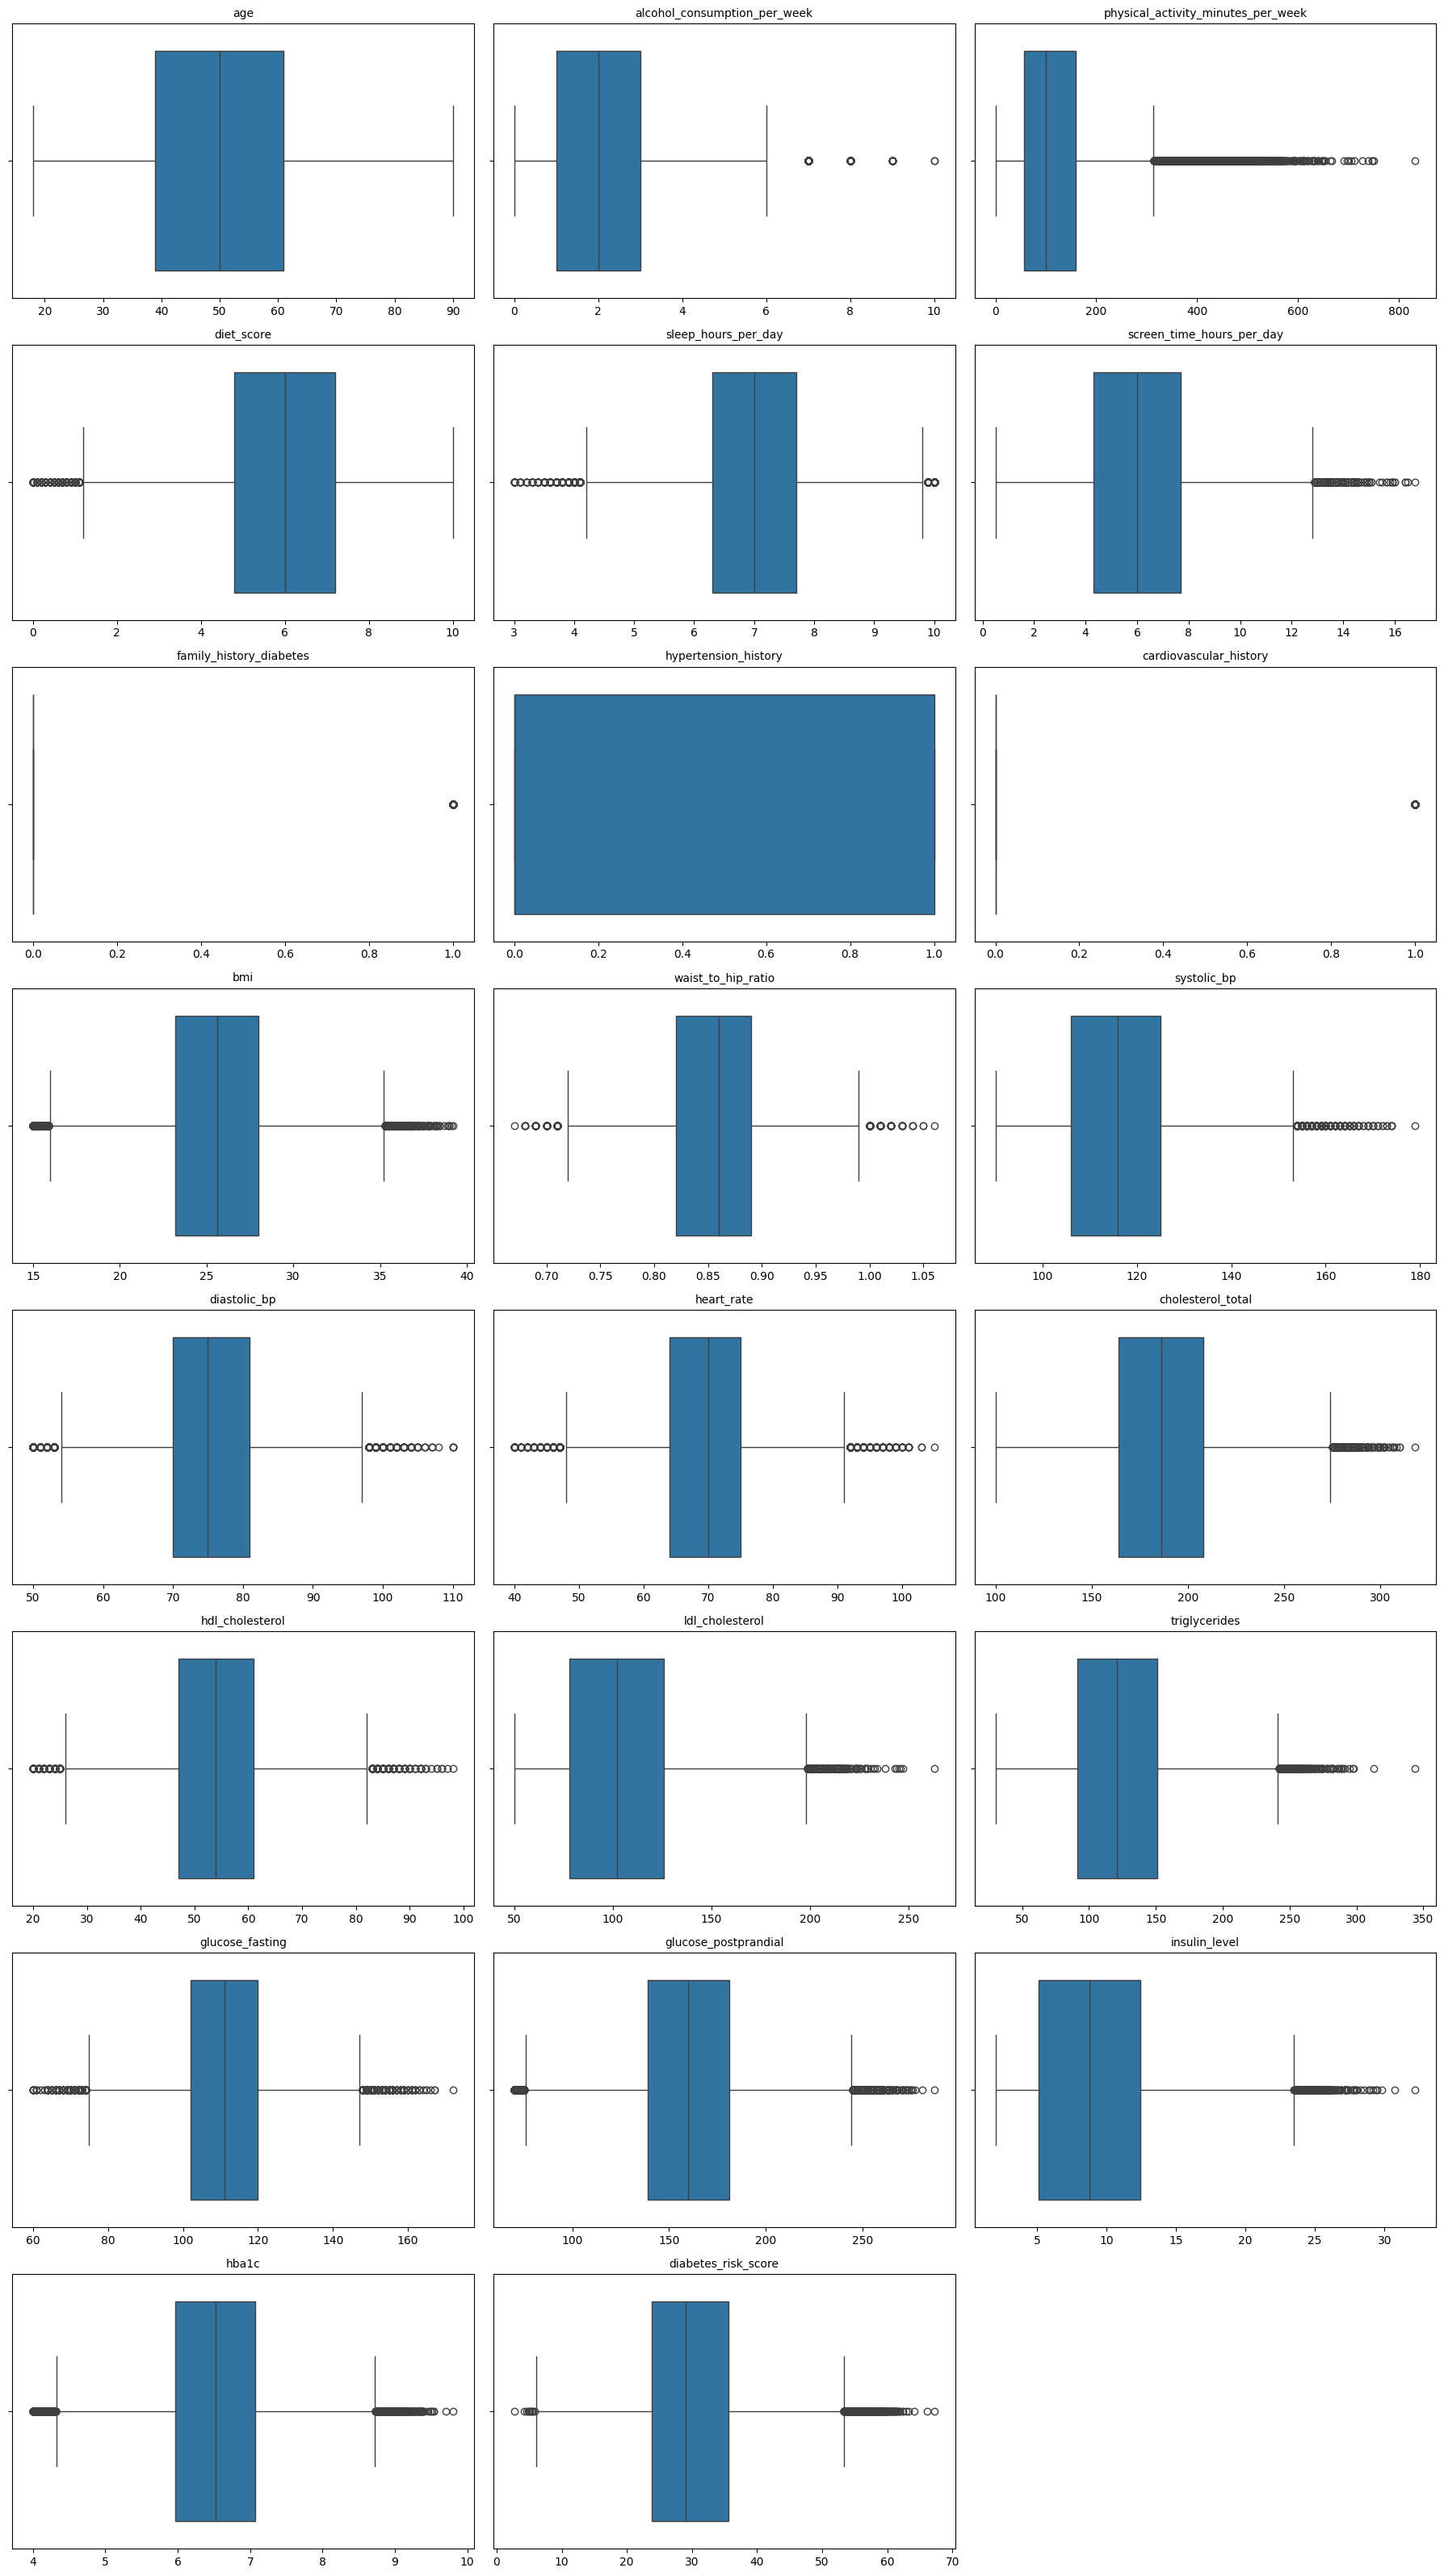

In [ ]:
## Detect Outliers using Boxplot in Numeric Columns
# Select numeric columns excluding 'diagnosed_diabetes'
numeric_cols = [col for col in Dibetes_df.select_dtypes(include=np.number).columns if col != 'diagnosed_diabetes']

# Define layout: 3 boxplots per row
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, column in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=Dibetes_df[column])
    plt.title(f'{column}', fontsize=10)
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

Some variables (like alcohol, physical activity, glucose, triglycerides) have many high outliers, meaning a few people have extremely high values.

Medical history (0/1) columns don’t have outliers.

Most people fall in normal healthy ranges, but outliers indicate potential health risks or exceptional behaviors.

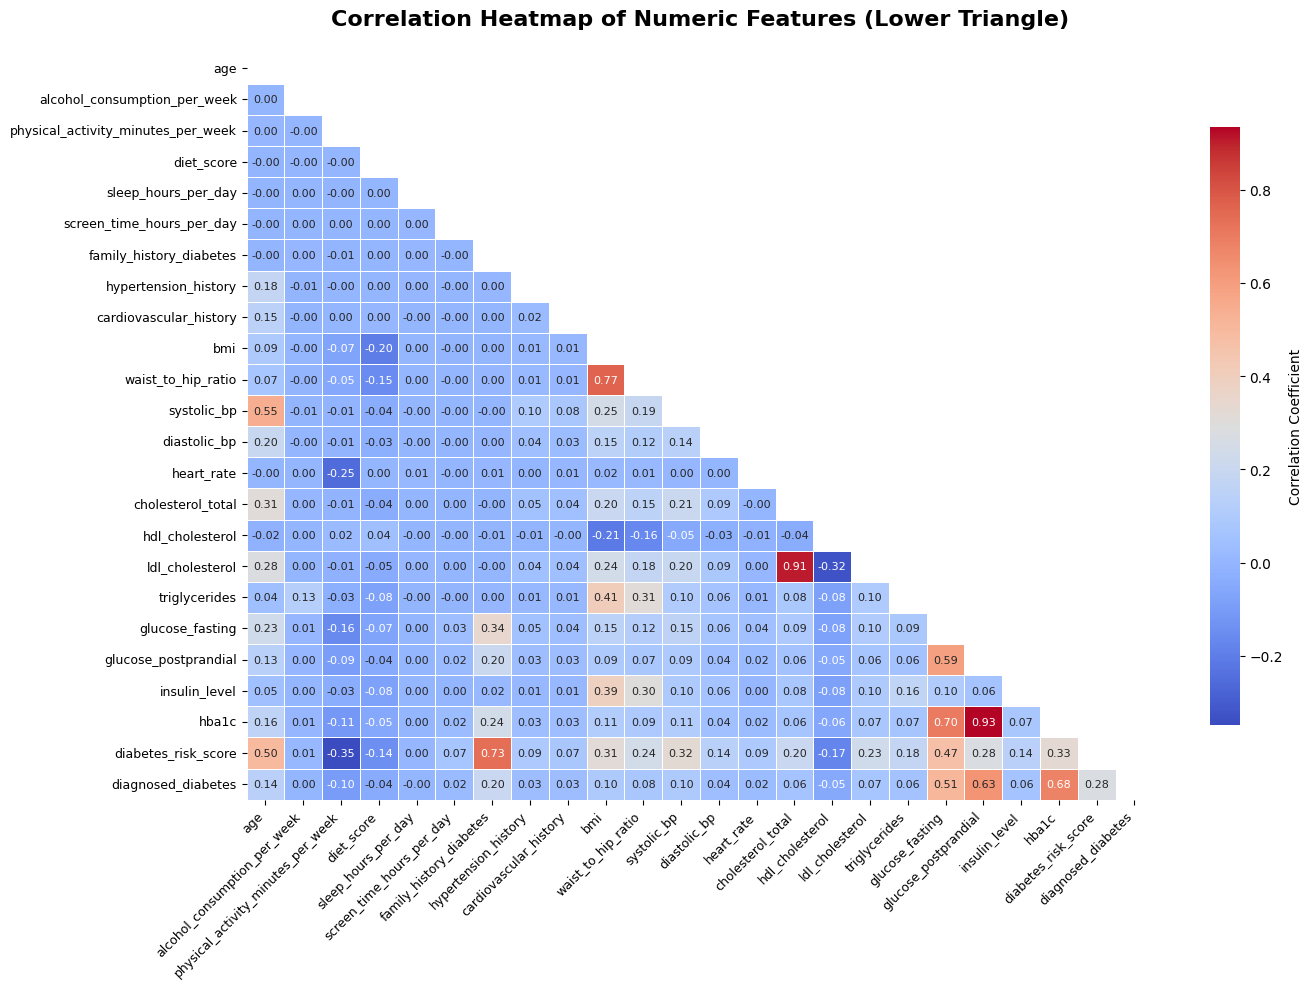

In [13]:
## Heatmap to show correlation between Numeric Columns
# Compute correlation matrix
# Select only numeric columns
numeric_df = Dibetes_df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = numeric_df.corr()

# Mask the upper triangle (including diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up figure
plt.figure(figsize=(14, 10))

# Draw heatmap
sns.heatmap(
    corr,
    mask=mask, 
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    annot_kws={"size": 8}
)

# Improve readability
plt.title("Correlation Heatmap of Numeric Features (Lower Triangle)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

plt.show()

##### Strongest clusters:

    Cholesterol-related features (ex:LDL, HDL, Total)

    Glucose-related features (ex:Glucose, HbA1c, Insulin, Risk score, Diabetes status)

    Body measures (ex:BMI, Waist-to-hip ratio)

##### Lifestyle variables (ex:alcohol, sleep, activity)
    show low direct correlations, suggesting their effects might be indirect or combined with other factors.

##### Medical indicators (ex: glucose and HbA1c)
    have the clearest relationships with diabetes risk and diagnosis

/tmp/ipykernel_27211/3171414054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_27211/3171414054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_27211/3171414054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_27211/3171414054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_27211/317

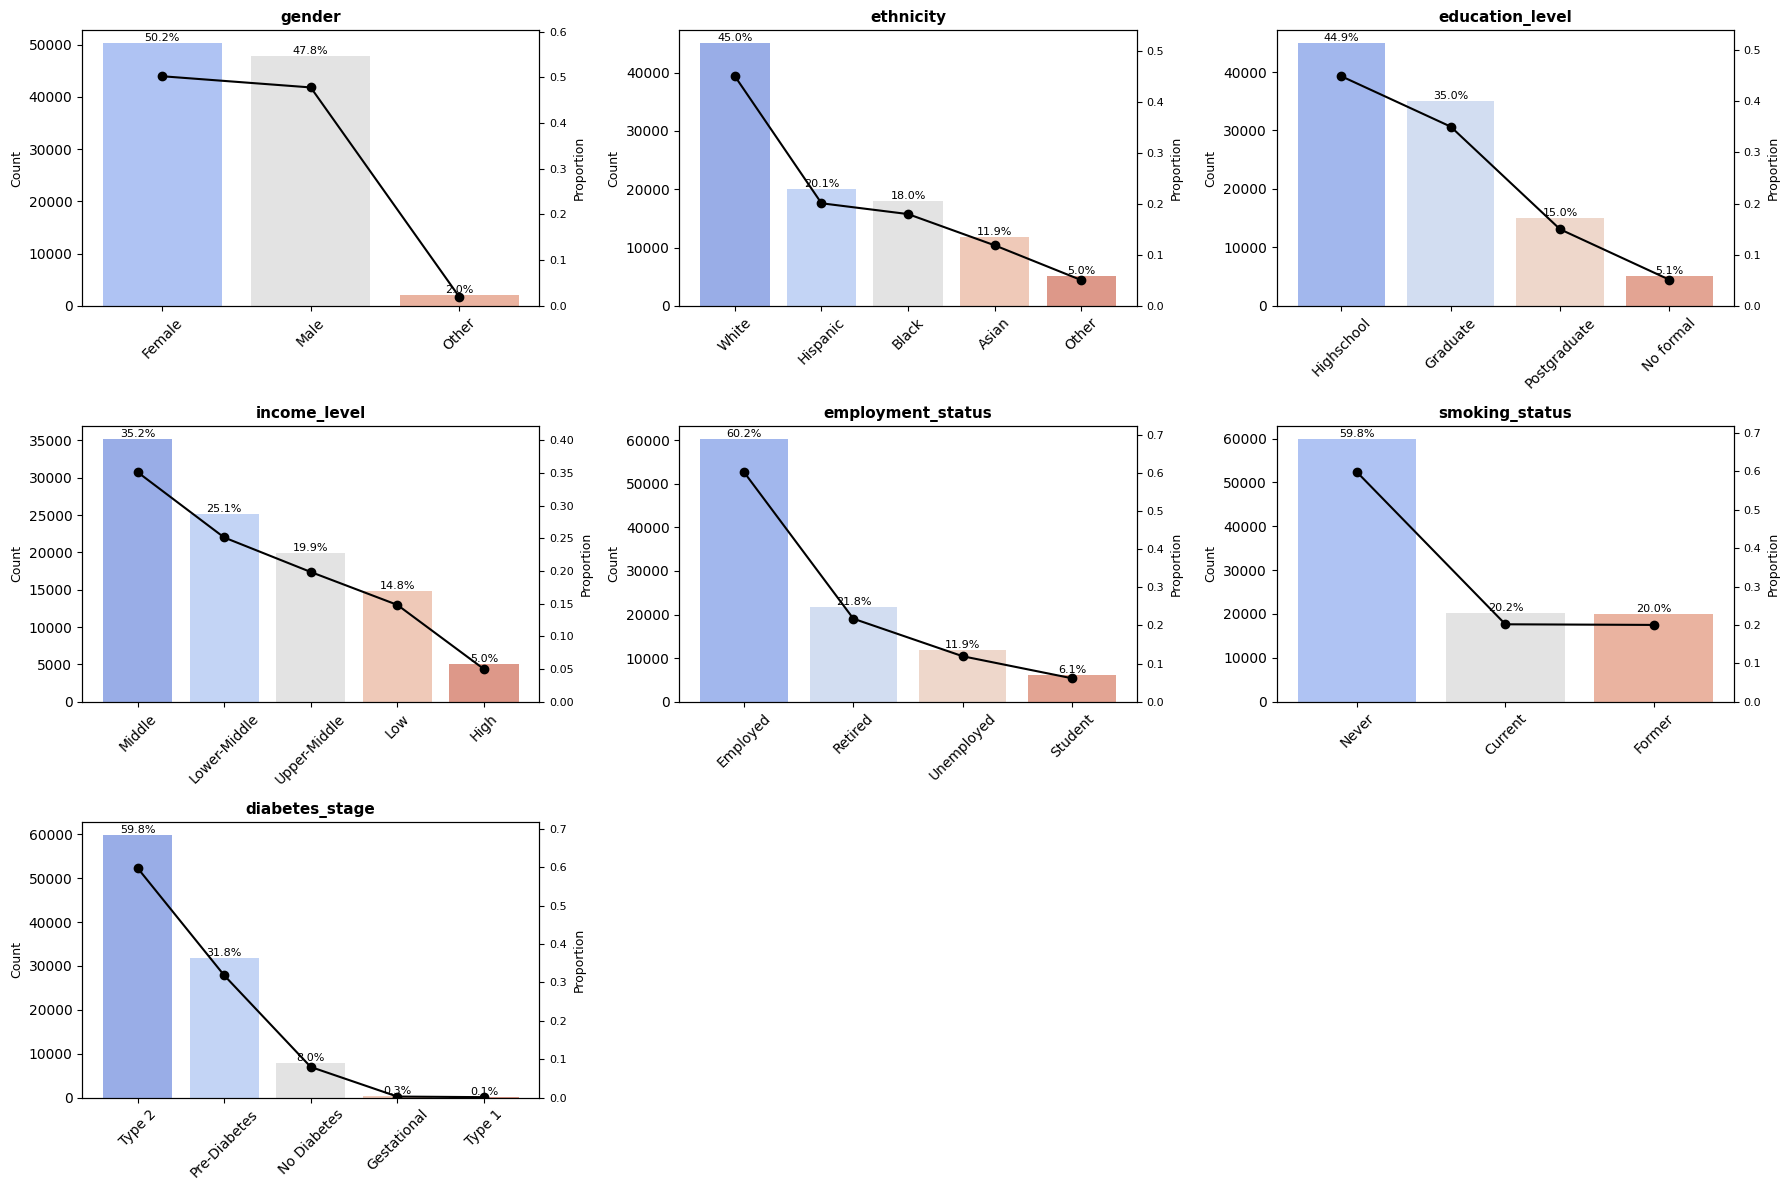

In [11]:
categorical_cols = Dibetes_df.select_dtypes(include='object').columns
# Number of rows & columns for layout
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, column in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Create the count plot
    ax = sns.countplot(
        x=Dibetes_df[column],
        order=Dibetes_df[column].value_counts().index,
        palette="coolwarm",
        alpha=0.8
    )

    # Add line for distribution trend
    counts = Dibetes_df[column].value_counts().values
    x_positions = np.arange(len(counts))
    ax2 = ax.twinx()
    ax2.plot(x_positions, counts / counts.sum(), color='black', marker='o', linewidth=1.5, label='Distribution')
    ax2.set_ylim(0, max(counts / counts.sum()) * 1.2)
    ax2.set_ylabel('Proportion', fontsize=9, color='black')
    ax2.tick_params(axis='y', labelsize=8)
    
    # Annotate percentage on bars
    total = len(Dibetes_df[column])
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height/total:.1%}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, color='black')

    # Titles and formatting
    ax.set_title(f'{column}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.legend([],[], frameon=False)
    
plt.tight_layout()
plt.show()


dataset has a mostly working-age, middle-income population.
Most people are employed, non-smokers, and have Type 2 diabetes or pre-diabetes, with balanced gender distribution and mainly White ethnicity.